In [1]:
import itk
from itk import RTK as rtk

from cil.io import ZEISSDataReader
from cil.framework import AcquisitionGeometry, ImageGeometry
from cil.processors import TransmissionAbsorptionConverter, Slicer, Binner
from cil.optimisation.algorithms import FISTA, ISTA
from cil.optimisation.functions import LeastSquares, TotalVariation
from cil.utilities.display import show2D
from ProxSkip import ProxSkip
# from TotalVariation import TotalVariationNew

from cil.optimisation.functions import SVRGFunction, SAGAFunction, SGFunction, SAGFunction
from cil.optimisation.utilities import MetricsDiagnostics, StatisticsDiagnostics, AlgorithmDiagnostics, RSE, RandomSampling
from cil.optimisation.functions import L2NormSquared, LeastSquares, MixedL21Norm, IndicatorBox, ZeroFunction, SGFunction, SAGAFunction, SVRGFunction, BlockFunction
# from ProxSkip import ProxSkip

from utils_RTK import build_rtk_geometry_from_cil_ag, cil_acquisitiondata_to_rtk_projection_image, \
                      reconstruct_fdk, RTKProjectionOperator

# import zarr
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['lines.linewidth'] = 5
plt.rcParams['lines.markersize'] = 5
plt.rcParams['font.size'] = 30

### Utils

In [2]:
def list_of_functions(data):
    
    list_funcs = []
    ig = data[0].geometry.get_ImageGeometry()
    
    for d in data:
        ageom_subset = d.geometry        
        Ai = RTKProjectionOperator(ig, ageom_subset, projector="joseph")
        fi = LeastSquares(Ai, b = d, c = 0.5)
        list_funcs.append(fi)   
        
    return list_funcs

from cil.optimisation.utilities import AlgorithmDiagnostics


class StoppingCriterionTime(AlgorithmDiagnostics):

    def __init__(self, time):

        self.time = time
        super(StoppingCriterionTime, self).__init__(verbose=0)

        self.should_stop = False
        
    def _should_stop(self):

        return self.should_stop       
            
    def __call__(self, algo):

        if algo.iteration==0:
            algo.should_stop = self._should_stop  

        stop_crit = np.sum(algo.timing)>self.time
        if stop_crit:
            self.should_stop = True                 
            print("Stop at {} time {}".format(algo.iteration, np.sum(algo.timing)))

### Load data

In [3]:
path = '/Users/evangelospapoutsellis/Desktop/CIL_work/ProxSkip/valnut/valnut_2014-03-21_643_28/tomo-A'
filename = os.path.join(path, "valnut_tomo-A.txrm")
data3D = ZEISSDataReader(file_name=filename).read()

# Get Image and Acquisition geometries
ag3D = data3D.geometry
ig3D = ag3D.get_ImageGeometry()

### Bin and slice

In [4]:
binned_data = Slicer(roi={'angle':(0,1600,4)})(data3D)
binned_data = Binner(roi={'vertical':(None,None,4), 'horizontal':(None,None,4)})(binned_data)
absorption_data = TransmissionAbsorptionConverter()(binned_data) 

### FDK Recon using RTK

In [5]:
ag = absorption_data.geometry.copy()

### problem with inital angle and RTK
ag.set_angles(ag.angles, initial_angle=0.2, angle_unit='radian')
rtk_geom, sid, sdd = build_rtk_geometry_from_cil_ag(ag)

print("RTK sid:", sid)
print("RTK sdd:", sdd)
print("num projections:", len(ag.angles))

projections_itk, projs_abs_np = cil_acquisitiondata_to_rtk_projection_image(
    absorption_data,
    apply_minus_log=False,  
)

RTK sid: 105.05081176757812
RTK sdd: 150.13838577270508
num projections: 400


In [6]:
ig = ag.get_ImageGeometry()

vol_size = list(ig.shape)
vol_spacing = [ig.voxel_size_z, ig.voxel_size_y, ig.voxel_size_x]
scale = 2.0

# first pixle in memory coords
vol_origin = [ -(vol_size[0] - 1) * vol_spacing[0] / scale, 
              -(vol_size[1] - 1) * vol_spacing[1] / scale, 
              -(vol_size[2] - 1) * vol_spacing[2] / scale, ]

In [7]:
recon = reconstruct_fdk(
    projections_img=projections_itk,   
    geometry=rtk_geom,                 
    vol_size=vol_size,
    vol_spacing=vol_spacing,
    vol_origin=vol_origin,
)

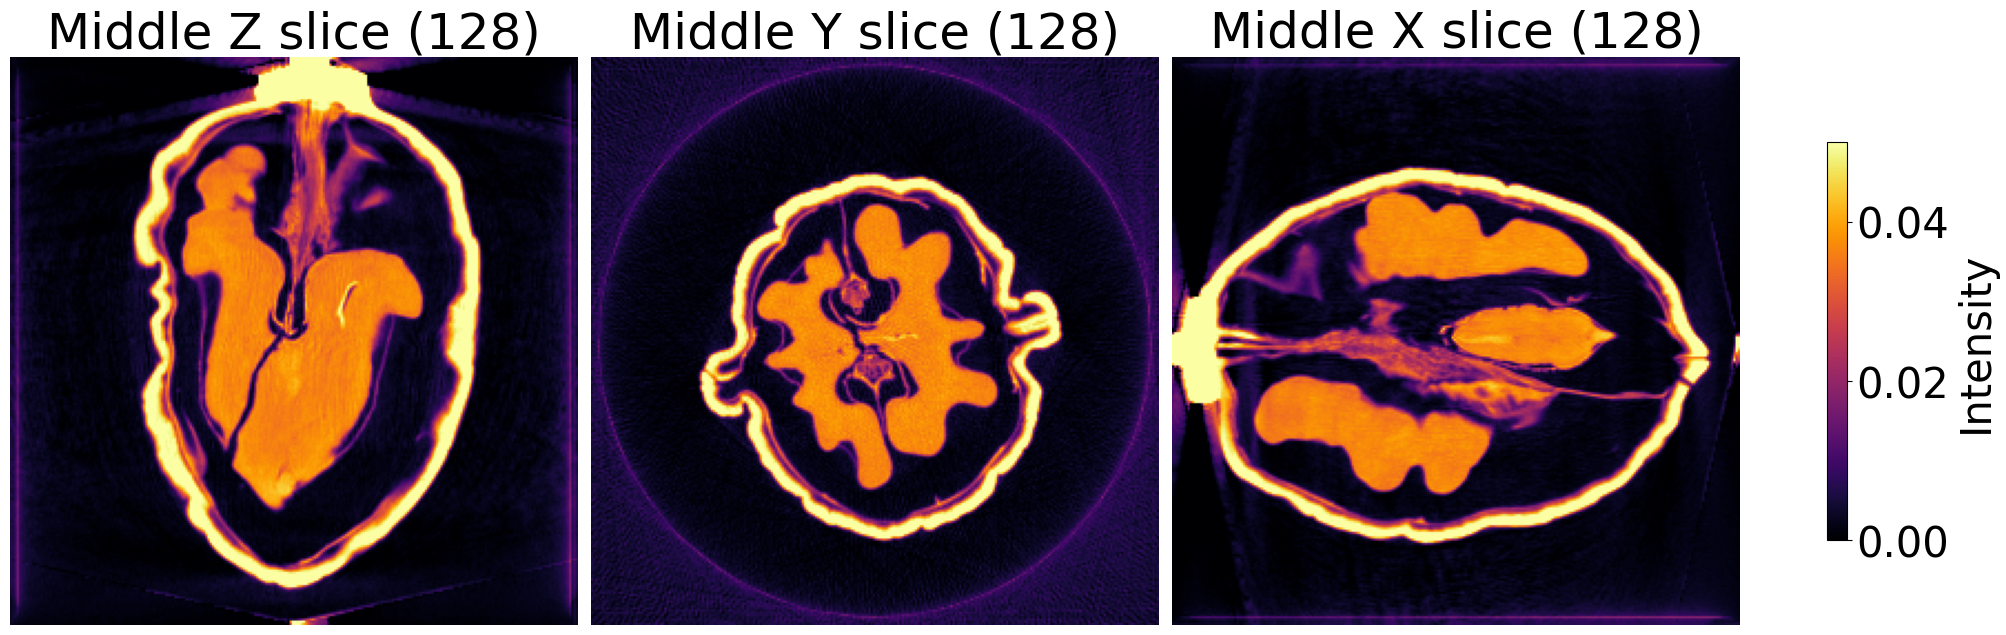

In [8]:
recon_np = itk.array_view_from_image(recon).copy()
recon_np[recon_np < 0] = 0

mid_z, mid_y, mid_x = [s // 2 for s in recon_np.shape]

fig, axes = plt.subplots(1, 3, figsize=(20, 20), constrained_layout=True)

im0 = axes[0].imshow(recon_np[mid_z, :, :], cmap="inferno", vmax=0.05)
axes[0].set_title(f"Middle Z slice ({mid_z})")
axes[0].axis("off")

im1 = axes[1].imshow(recon_np[:, mid_y, :], cmap="inferno", vmax=0.05)
axes[1].set_title(f"Middle Y slice ({mid_y})")
axes[1].axis("off")

im2 = axes[2].imshow(recon_np[:, :, mid_x], cmap="inferno", vmax=0.05)
axes[2].set_title(f"Middle X slice ({mid_x})")
axes[2].axis("off")

fig.colorbar(im2, ax=axes, shrink=0.2, label="Intensity")
plt.show()

### Iterative Recon

In [9]:
absorption_data = TransmissionAbsorptionConverter()(binned_data) 
ag = absorption_data.geometry.copy()
ag.set_angles(ag.angles, initial_angle=0.2, angle_unit='radian')
absorption_data.array = absorption_data.array[::-1]

In [10]:
ig = ag.get_ImageGeometry()

In [11]:
print(ig)
print(ag)

Number of channels: 1
channel_spacing: 1.0
voxel_num : x256,y256,z256
voxel_size : x0.1843112207883579,y0.1843112207883579,z0.1843112207883579
center : x0,y0,z0

3D Cone-beam tomography
System configuration:
	Source position: [   0.        , -105.05081177,    0.        ]
	Rotation axis position: [0., 0., 0.]
	Rotation axis direction: [0., 0., 1.]
	Detector position: [ 0.        , 45.08757401,  0.        ]
	Detector direction x: [1., 0., 0.]
	Detector direction y: [0., 0., 1.]
Panel configuration:
	Number of pixels: [256 256]
	Pixel size: [0.26341719 0.26341719]
	Pixel origin: bottom-left
Channel configuration:
	Number of channels: 1
Acquisition description:
	Number of positions: 400
	Angles 0-20 in radians:
[-3.1415668, -3.125836 , -3.1101887, -3.0944946, -3.0787866, -3.0630565,
 -3.0473695, -3.031667 , -3.0159605, -3.0002484, -2.9845278, -2.968836 ,
 -2.95312  , -2.937424 , -2.9217167, -2.906006 , -2.8902867, -2.874609 ,
 -2.8588805, -2.8431616]
Distances in units: units distance


In [12]:
### due to memory, problems with objective values??
def __call__(self, x):
        
    r""" Returns the value of :math:`F(x) = c\|Ax-b\|_2^2` or c\|Ax-b\|_{2,weight}^2
                    
    """
    y = self.A.direct(x)
    y -= self.b
    
    if self.weight is None:    
        return self.c * y.dot(y)
    else:
        wy = self.weight.multiply(y)
        return self.c * y.dot(wy)
LeastSquares.__call__ = __call__

### Avoid computing objectives, not needed for this demo
def update_objective(self):
    return 0.

ProxSkip.update_objective = update_objective
FISTA.update_objective = update_objective

In [16]:
PO = RTKProjectionOperator(ig, ag, projector="joseph")
F = LeastSquares(PO, b=absorption_data, c=0.5)
alpha = 0.01
G =  alpha * TotalVariation(max_iteration=10, lower=0.)
initial = ig.allocate()

### Adjoint test

In [13]:
PO.adjoint_test()

<Ax, b>     = -1.05220930e+04
<x, A^T b>  = -1.05220832e+04
abs error   = 9.86364870e-03
rel error   = 9.37422684e-07


{'lhs': -10522.093049683437,
 'rhs': -10522.083186034733,
 'abs_err': 0.009863648703685612,
 'rel_err': 9.374226835964319e-07}

In [28]:
# computed once but takes time 
step_size = 0.00029449443391933174 # for 4x binned/sliced data

max_iteration = 100
time_stop = 3*60

In [29]:
cb_time = StoppingCriterionTime(time_stop)
fista = FISTA(initial = initial, f = F, step_size = 0.00029449443391933174, g=G, 
        update_objective_interval = 1, 
        max_iteration = max_iteration) 
fista.run(verbose=0, callback=[cb_time])
# fista.run(10, verbose=0, callback=[cb_metrics, cb_time])


Stop at 4 time 182.21509671211243


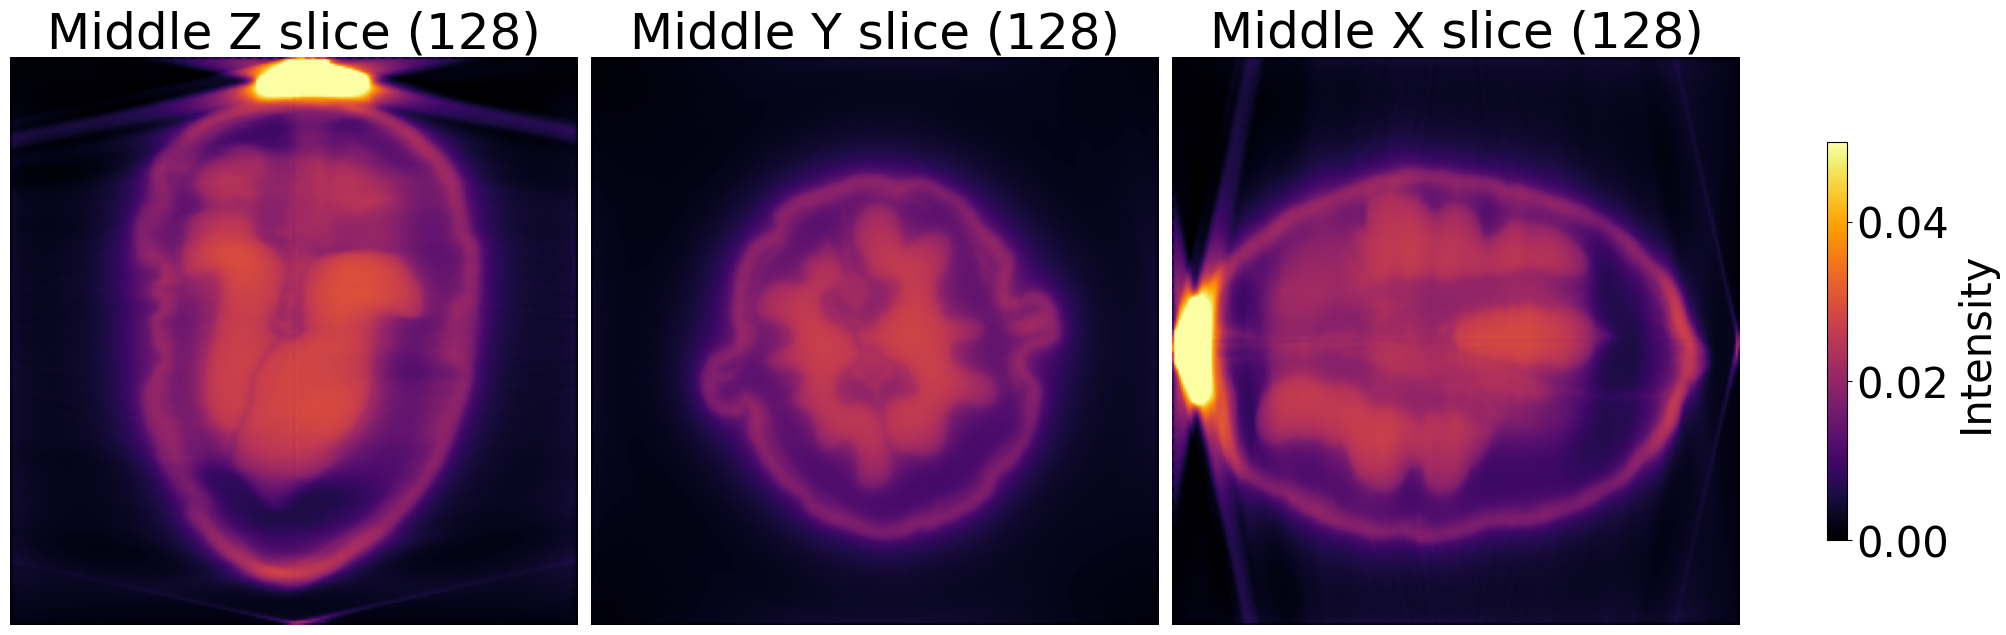

In [40]:
mid_z, mid_y, mid_x = [s // 2 for s in recon_np.shape]

fig, axes = plt.subplots(1, 3, figsize=(20, 20), constrained_layout=True)
vmax = 0.05
im0 = axes[0].imshow(fista.solution.array[mid_z, :, :], cmap="inferno", vmax=vmax)
axes[0].set_title(f"Middle Z slice ({mid_z})")
axes[0].axis("off")

im1 = axes[1].imshow(fista.solution.array[:, mid_y, :], cmap="inferno", vmax=vmax)
axes[1].set_title(f"Middle Y slice ({mid_y})")
axes[1].axis("off")

im2 = axes[2].imshow(fista.solution.array[:, :, mid_x], cmap="inferno", vmax=vmax)
axes[2].set_title(f"Middle X slice ({mid_x})")
axes[2].axis("off")

fig.colorbar(im2, ax=axes, shrink=0.2, label="Intensity")
plt.show()

### ProxSkip-SGD

In [30]:
nsub = 100
data_split, method = absorption_data.split_to_subsets(nsub, method= "ordered", info=True)
list_func = list_of_functions(data_split) 

In [31]:
selection = RandomSampling(len(list_func), nsub, seed=42)
Fsgd = SGFunction(list_func, selection = selection)
Fsgd.initial = initial

In [32]:
cb_time = StoppingCriterionTime(time_stop)
proxskip_sgd = ProxSkip(initial = [initial, initial], f = Fsgd, step_size = step_size, g=G, 
            update_objective_interval = 1, prob=0.1, seed = 42,
            max_iteration = max_iteration) 
proxskip_sgd.run(verbose=0, callback=[cb_time])
# proxskip_sgd.run(100, verbose=1)

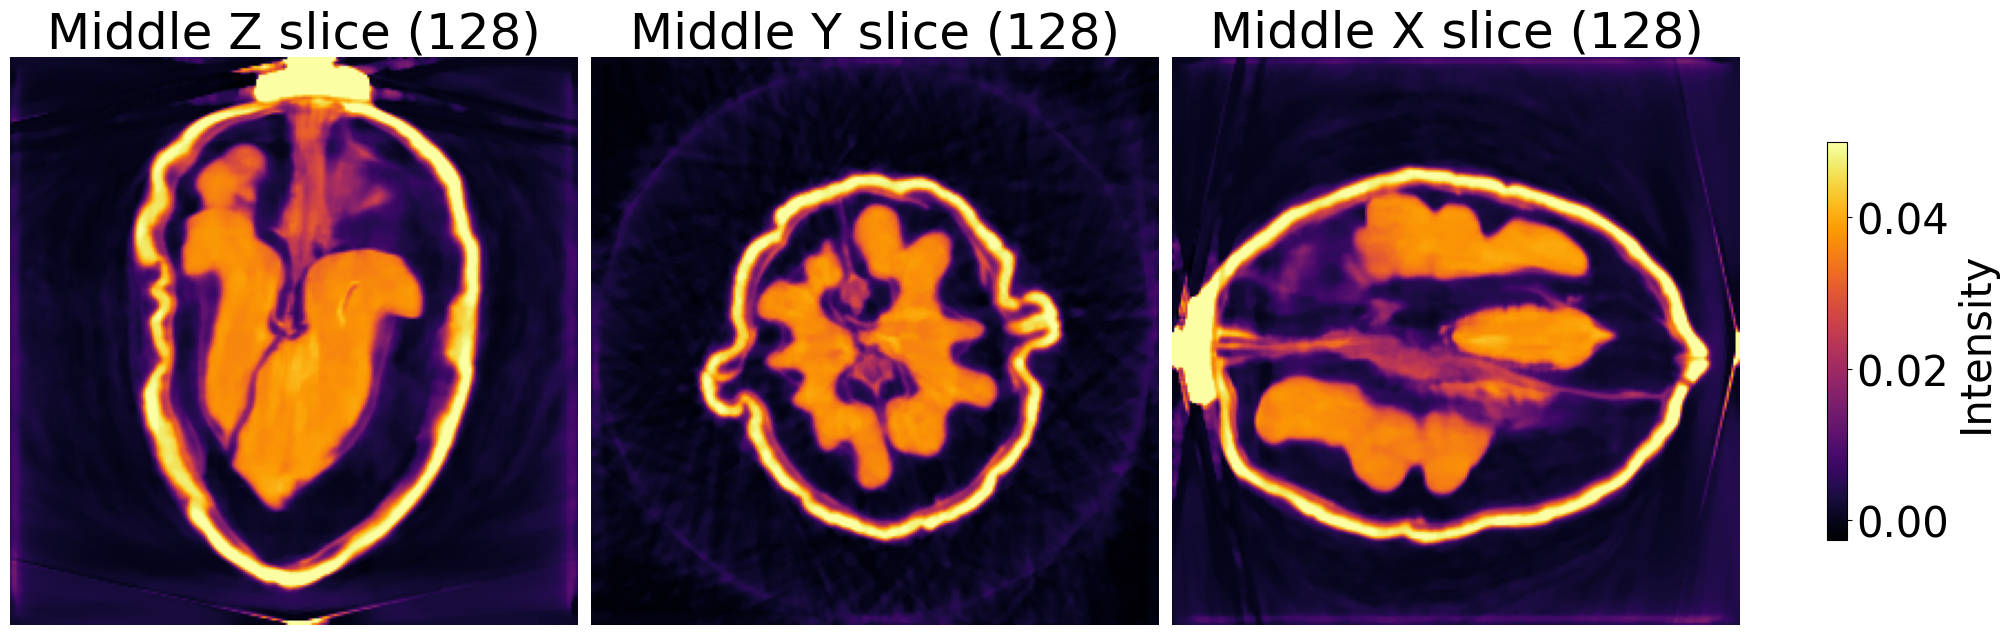

In [41]:
mid_z, mid_y, mid_x = [s // 2 for s in recon_np.shape]

fig, axes = plt.subplots(1, 3, figsize=(20, 20), constrained_layout=True)

im0 = axes[0].imshow(proxskip_sgd.solution.array[mid_z, :, :], cmap="inferno", vmax=vmax)
axes[0].set_title(f"Middle Z slice ({mid_z})")
axes[0].axis("off")

im1 = axes[1].imshow(proxskip_sgd.solution.array[:, mid_y, :], cmap="inferno", vmax=vmax)
axes[1].set_title(f"Middle Y slice ({mid_y})")
axes[1].axis("off")

im2 = axes[2].imshow(proxskip_sgd.solution.array[:, :, mid_x], cmap="inferno", vmax=vmax)
axes[2].set_title(f"Middle X slice ({mid_x})")
axes[2].axis("off")

fig.colorbar(im2, ax=axes, shrink=0.2, label="Intensity")
plt.show()